# Purpose
Interpret IBDSeq results and compare IBD length distribution between the ground-truth and the reported.

# Output
- Reported IBD segment length distribution
- Overlap of ground-truth & reported IBD length distribution

In [3]:
import pandas as pd
ibd_report = pd.read_csv("../results/anopheles_ibd.ibd", sep="\t", header=None)
ibd_report.columns = ["id1", "id1 haplotype index", "id2", "id2 haplotype index", "chr", "start", "end", "LOD score"]
ibd_report["length"] = ibd_report["end"] - ibd_report["start"]  
ibd_report.head()

pred_df = ibd_report[ibd_report["length"] > 20000]
pred_df["length_Mb"] = pred_df["length"]/1000000


true_df = pd.read_csv("../data/ibd_Truth.csv", sep=",") 
true_df["length_Mb"] = true_df["length"] / 1000000

CPU times: user 28.6 ms, sys: 8.08 ms, total: 36.7 ms
Wall time: 37.4 ms


,id1,id1 haplotype index,id2,id2 haplotype index,chr,start,end,LOD score,length
0,tsk_0,0,tsk_1,0,1,27892,37676,3.43,9784
1,tsk_0,0,tsk_1,0,1,45405,51135,3.22,5730
2,tsk_0,0,tsk_1,0,1,807916,845506,4.97,37590
3,tsk_0,0,tsk_3,0,1,1264951,1278649,4.38,13698
4,tsk_0,0,tsk_3,0,1,1570112,1590649,5.43,20537


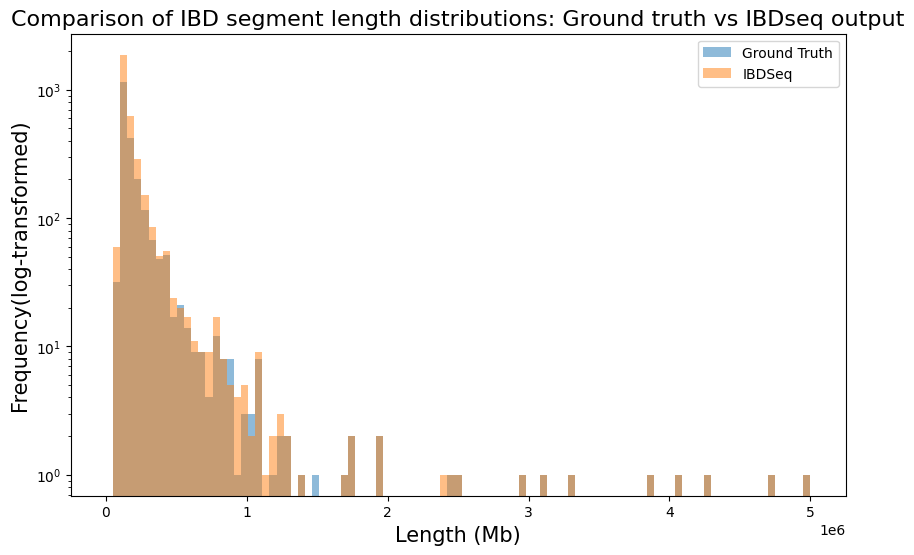

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.linewidth'] = 1.2


bins = np.linspace(0, 5.0, 100) 
fig, ax = plt.subplots(figsize=(10,7))

color_true_df = '#2d89c2'  
color_pred_df = '#ffa83f'

ax.hist(true_df["length_Mb"], bins=bins, alpha=0.4, color=color_true_df, 
        label=f"Ground Truth (N={len(true_df):,})", log=True)
ax.hist(pred_df["length_Mb"], bins=bins, alpha=0.6, color=color_pred_df, 
        label=f"IBDSeq (N={len(pred_df):,})", log=True)
ax.set_xlabel("Segment Length (Mb)", fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel("Frequency (log)", fontsize=13, fontweight='bold', labelpad=12)

ax.set_xlim(-0.1, 5.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)


plt.tight_layout()
plt.savefig("../results/IBDlengthDist_Ground-truth&IBDSeq (Simulation#1).png")


plt.show()

In [ ]:
# Refined IBD vs IBDSeq against ground-truth:
import numpy as np
import matplotlib.pyplot as plt


bins = np.linspace(0, 5.0, 100) 
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(9.5, 6))


ax.hist(true_df["length_Mb"], bins=bins, histtype='step', linewidth=2, color='#E0E0E0', fill=True,
        label=f"Ground Truth (N={len(ibd_truth):,})", log=True)
ax.hist(pred_df_IBDseq["length_Mb"], bins=bins, histtype='step', linewidth=1.5, color='#2C7BB6', 
        label=f"IBDseq (N={len(ibd_filtered):,})", log=True)
ax.hist(pred_df_RefinedIBD["cM length of IBD segment"], bins=bins, histtype='step', linewidth=1.5, color='#D7191C', 
        label=f"Refined IBD (N={len(Refined_ibd):,})", log=True)

ax.set_xlabel("Segment Length (Mb)", fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel("Frequency (log scale)", fontsize=13, fontweight='bold', labelpad=12)
ax.set_title("Comparison of IBD Segment Length Distributions:\nGround Truth vs IBDseq vs Refined IBD", 
             fontsize=14, pad=18, fontweight='bold')

ax.set_xlim(-0.1, 5.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=11)


plt.tight_layout()

plt.savefig("GroundTruth_vs_IBDSeq_vs_RefinedIBD_distribution.pdf", format="pdf", bbox_inches='tight')
plt.savefig("GroundTruth_vs_IBDSeq_vs_RefinedIBD_distribution.png", format="png", bbox_inches='tight')
plt.savefig("../results/GroundTruth_vs_IBDSeq_vs_RefinedIBD_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()